#####**Goal**: Understand the dataset, uncover business insights, identify patterns, and create high-quality visualizations for your report and Power BI dashboard.

####Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import string

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer

plt.style.use("ggplot")

sns.set_palette("Set2")

####Load Dataset

In [ ]:
df = pd.read_csv(
    "/content/clean_reviews.csv"
)

print(df.shape)

df.head()

(21054, 13)


,review_id,product_category,timestamp,country,rating,review,sentiment,date,year,month,month_name,weekday,hour
0,REV-50BCBCD9,Sports,2024-09-16 13:44:26+00:00,US,1,"I registered on the website, tried to order a ...",Negative,2024-09-16,2024,9,September,Monday,13
1,REV-6D2B2651,Toys,2024-09-16 18:26:46+00:00,GB,1,Had multiple orders one turned up and driver h...,Negative,2024-09-16,2024,9,September,Monday,18
2,REV-F7E80372,Toys,2024-09-16 21:47:39+00:00,GB,1,I informed these reprobates that I WOULD NOT B...,Negative,2024-09-16,2024,9,September,Monday,21
3,REV-ED2B173F,Sports,2024-09-17 07:15:49+00:00,AU,1,I have bought from Amazon before and no proble...,Negative,2024-09-17,2024,9,September,Tuesday,7
4,REV-E48A7AB9,Fashion,2024-09-16 18:37:17+00:00,GB,1,If I could give a lower rate I would! I cancel...,Negative,2024-09-16,2024,9,September,Monday,18


####Overview

In [ ]:
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21054 entries, 0 to 21053
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_id         21054 non-null  object
 1   product_category  21054 non-null  object
 2   timestamp         21054 non-null  object
 3   country           21054 non-null  object
 4   rating            21054 non-null  int64 
 5   review            21054 non-null  object
 6   sentiment         21054 non-null  object
 7   date              21054 non-null  object
 8   year              21054 non-null  int64 
 9   month             21054 non-null  int64 
 10  month_name        21054 non-null  object
 11  weekday           21054 non-null  object
 12  hour              21054 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 2.1+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
review_id,21054,21054,REV-4765654E,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category,21054,7,Sports,3144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,21054,21053,2022-10-05 12:13:39+00:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,21054,148,US,9286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,21054.0,NaN,NaN,NaN,2.18652,1.676697,1.0,1.0,1.0,4.0,5.0
review,21054,20406,Review text not found,630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment,21054,3,Negative,14350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,21054,3655,2021-01-11,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,21054.0,NaN,NaN,NaN,2020.391897,3.308426,2007.0,2019.0,2021.0,2023.0,2024.0
month,21054.0,NaN,NaN,NaN,6.57343,3.491717,1.0,4.0,7.0,10.0,12.0


####Missing values

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)

missing

,0
review_id,0
product_category,0
timestamp,0
country,0
rating,0
review,0
sentiment,0
date,0
year,0
month,0


####Sentiment Distribution

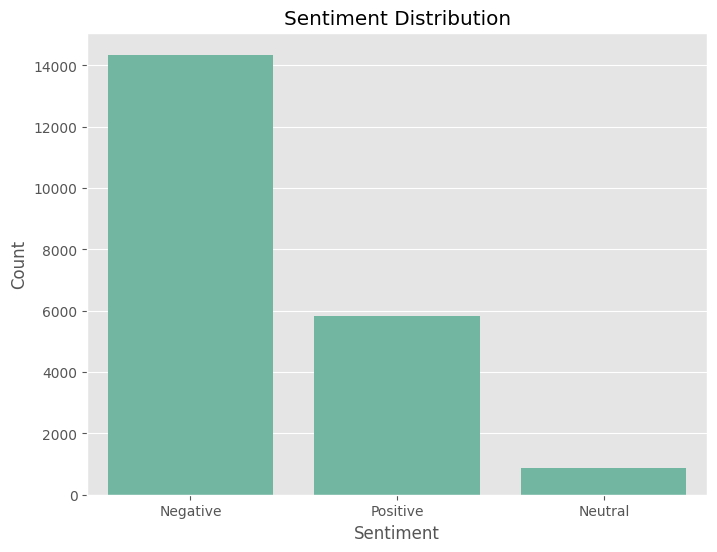

In [ ]:
import os

plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="sentiment",
    order=df["sentiment"].value_counts().index
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

# Create the directory
os.makedirs("Shopease/outputs/figures/", exist_ok=True)

plt.savefig(
    "Shopease/outputs/figures/sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

####Rating Distribution

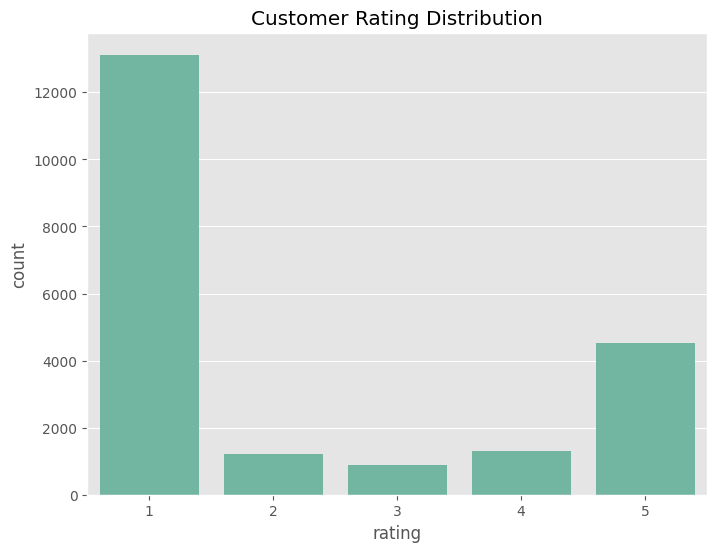

In [ ]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="rating"
)

plt.title("Customer Rating Distribution")

plt.savefig(
    "Shopease/outputs/figures/rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

####Country Distribution

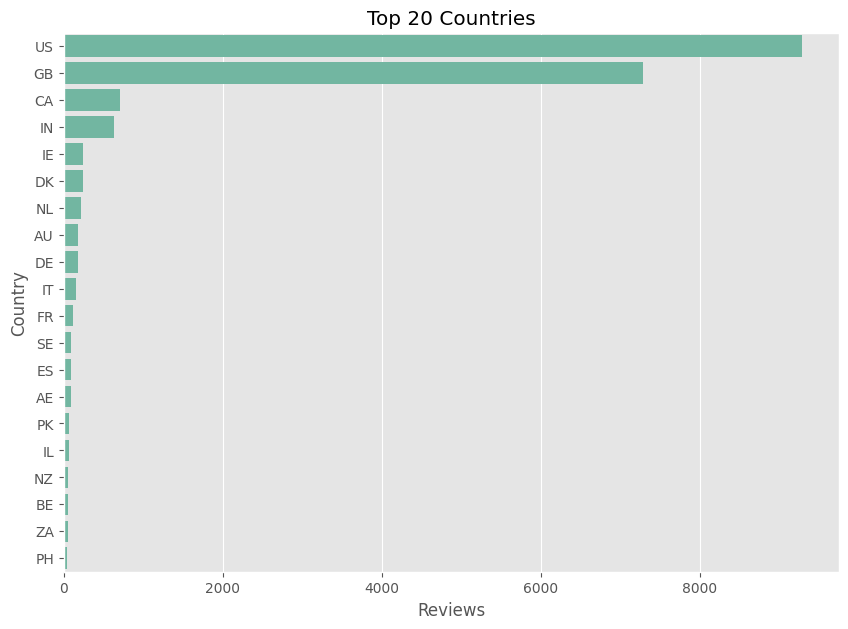

In [ ]:
top_countries = (
    df["country"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10,7))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 20 Countries")

plt.xlabel("Reviews")

plt.ylabel("Country")

plt.savefig(
    "Shopease/outputs/figures/country_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

####Product Category Distribution

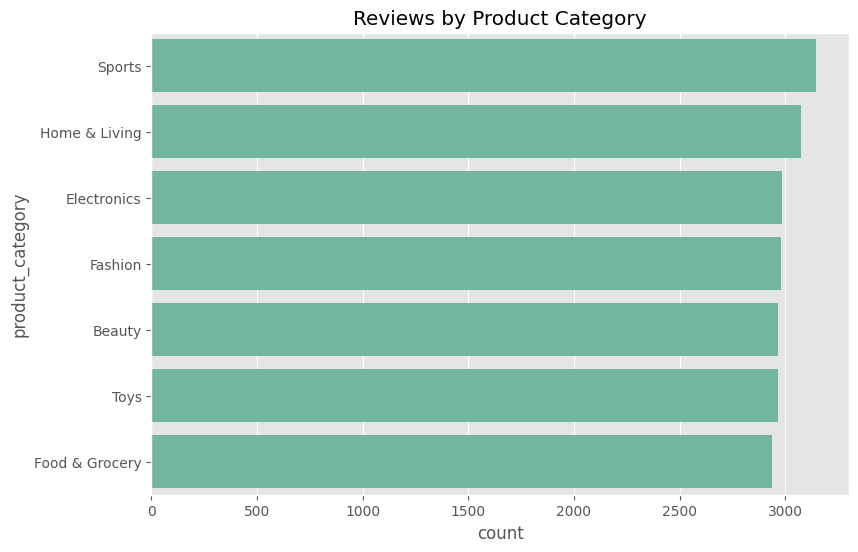

In [ ]:
plt.figure(figsize=(9,6))

sns.countplot(
    data=df,
    y="product_category",
    order=df["product_category"].value_counts().index
)

plt.title("Reviews by Product Category")

plt.savefig(
    "Shopease/outputs/figures/product_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

####Monthly Trend

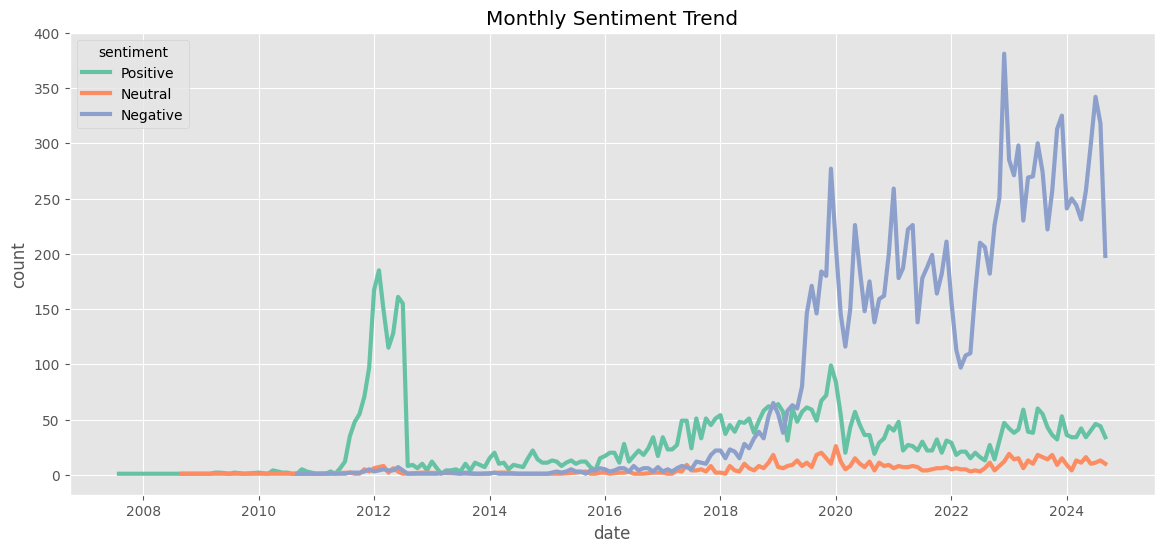

In [ ]:
monthly = (
    df.groupby(
        ["year","month","sentiment"]
    )
    .size()
    .reset_index(name="count")
)

monthly["date"] = pd.to_datetime(
    monthly["year"].astype(str)
    + "-"
    + monthly["month"].astype(str)
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly,
    x="date",
    y="count",
    hue="sentiment",
    linewidth=3
)

plt.title("Monthly Sentiment Trend")

plt.savefig(
    "Shopease/outputs/figures/monthly_sentiment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

####Rating vs Sentiment

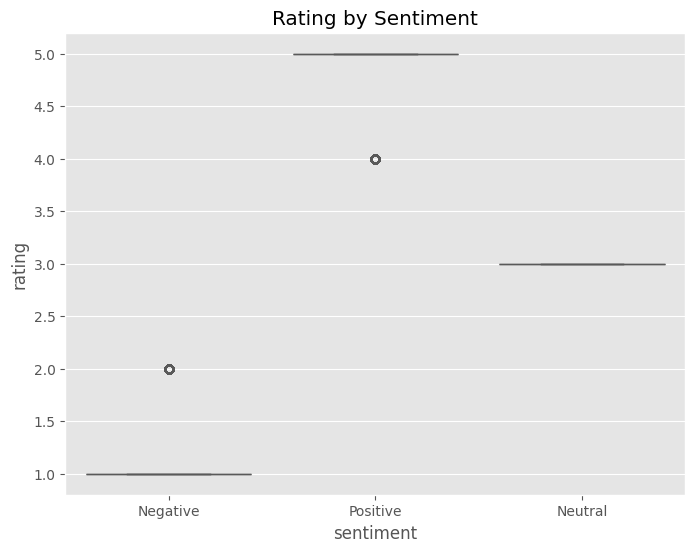

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="sentiment",
    y="rating"
)

plt.title("Rating by Sentiment")

plt.savefig(
    "Shopease/outputs/figures/rating_sentiment_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

####Review Length

In [ ]:
df["review_length"] = (
    df["review"]
    .astype(str)
    .str.split()
    .apply(len)
)

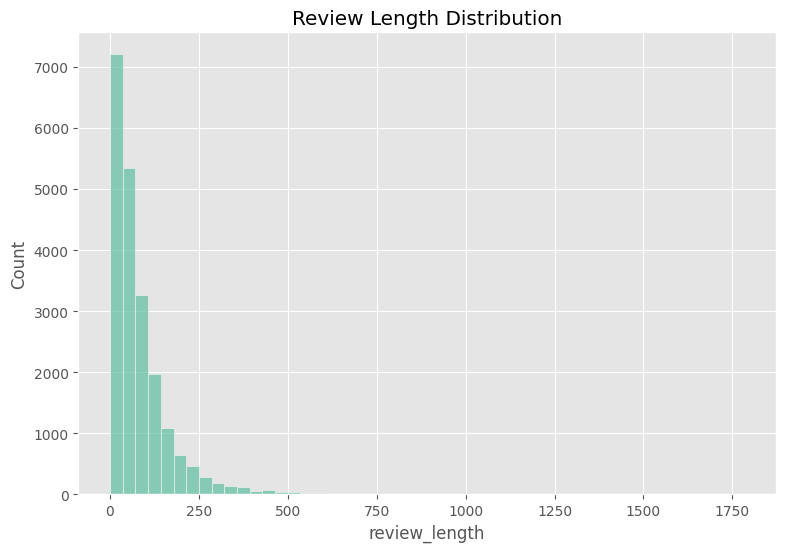

In [ ]:
plt.figure(figsize=(9,6))

sns.histplot(
    df["review_length"],
    bins=50
)

plt.title("Review Length Distribution")

plt.savefig(
    "Shopease/outputs/figures/review_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

####Review Length vs Sentiment

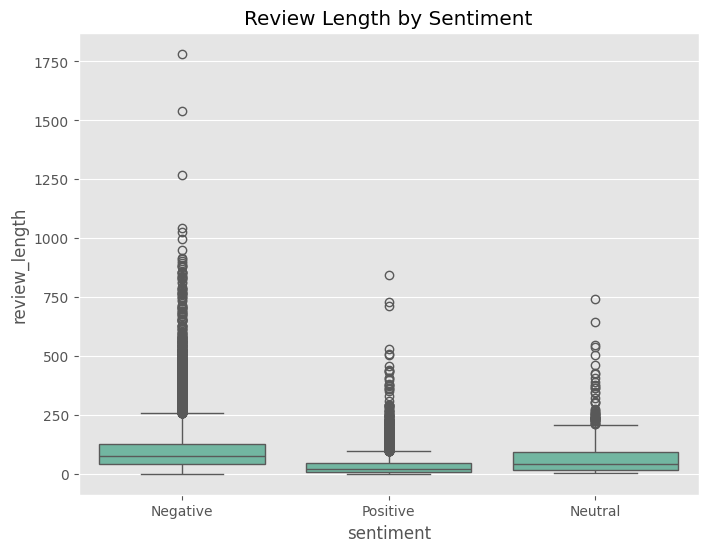

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="sentiment",
    y="review_length"
)

plt.title("Review Length by Sentiment")

plt.savefig(
    "Shopease/outputs/figures/review_length_sentiment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

####Sentiment by Country

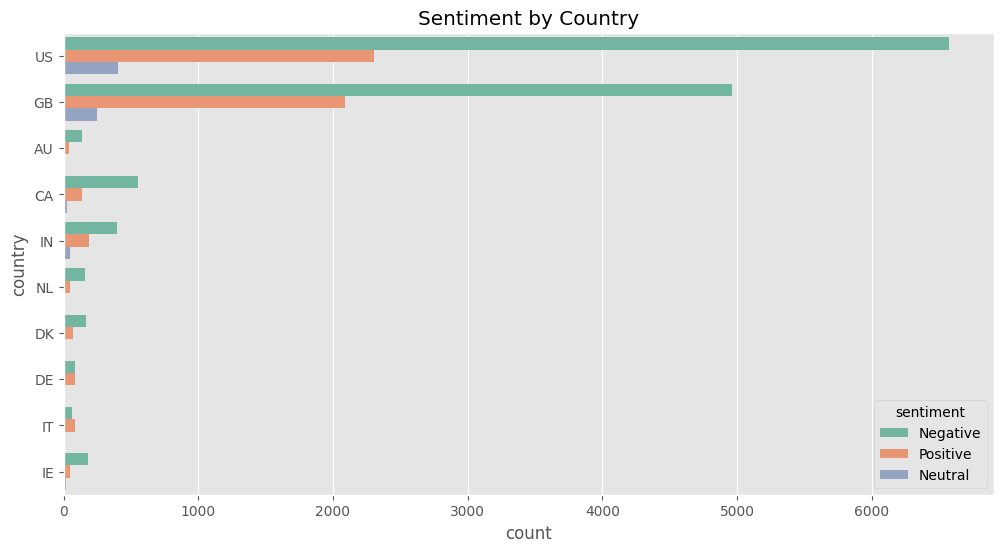

In [ ]:
top10 = (
    df["country"]
    .value_counts()
    .head(10)
    .index
)

country_df = df[
    df["country"].isin(top10)
]

plt.figure(figsize=(12,6))

sns.countplot(
    data=country_df,
    y="country",
    hue="sentiment"
)

plt.title("Sentiment by Country")

plt.savefig(
    "Shopease/outputs/figures/sentiment_country.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

####Sentiment by Product Category

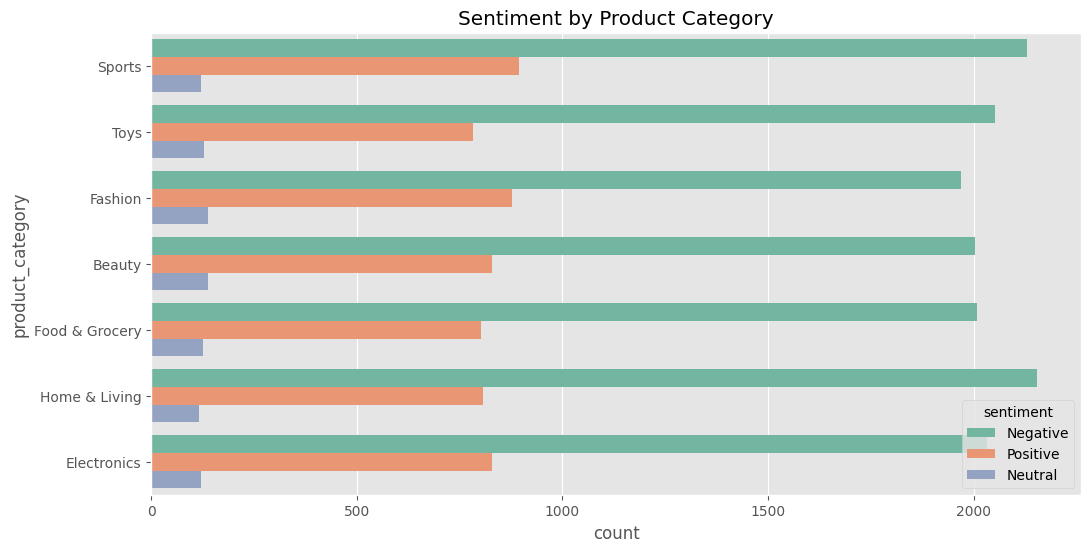

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="product_category",
    hue="sentiment"
)

plt.title("Sentiment by Product Category")

plt.savefig(
    "Shopease/outputs/figures/sentiment_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

####Correlation

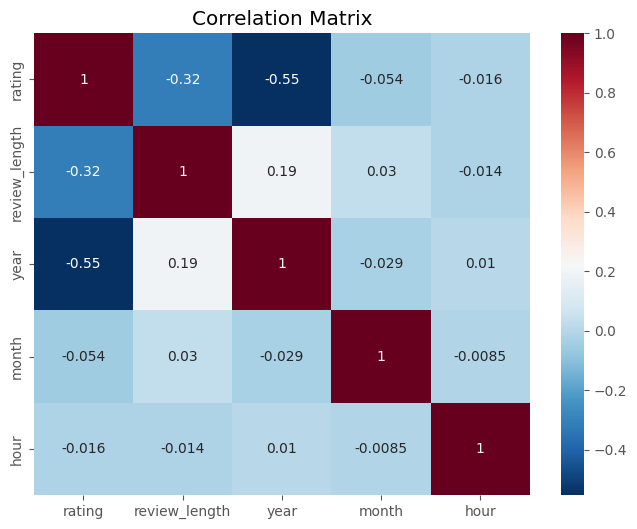

In [ ]:
numeric = df[
    [
        "rating",
        "review_length",
        "year",
        "month",
        "hour"
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="RdBu_r"
)

plt.title("Correlation Matrix")

plt.savefig(
    "Shopease/outputs/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

####WordCloud

#####Positive

In [ ]:
positive = " ".join(
    df[
        df["sentiment"]=="Positive"
    ]["review"]
)

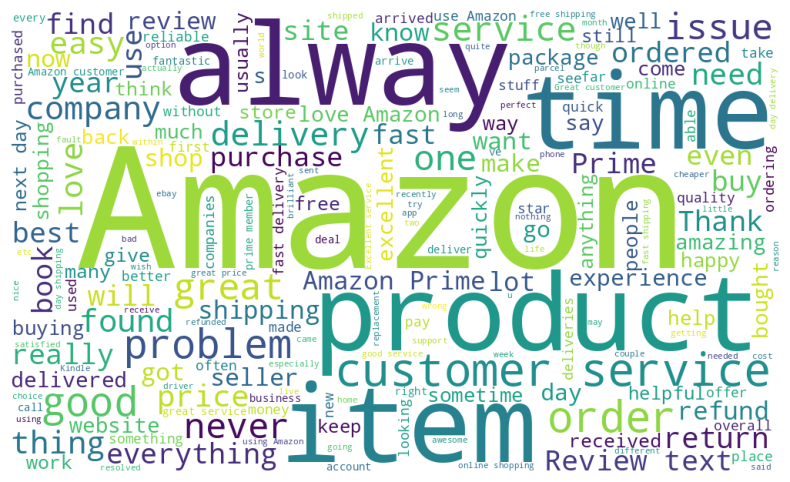

In [ ]:
wc = WordCloud(
    width=1000,
    height=600,
    background_color="white"
)

plt.figure(figsize=(12,6))

plt.imshow(
    wc.generate(positive)
)

plt.axis("off")

plt.savefig(
    "Shopease/outputs/figures/positive_wordcloud.png",
    dpi=300
)

plt.show()

#####Negative

In [ ]:
negative = " ".join(
    df[
        df["sentiment"]=="Negative"
    ]["review"]
)

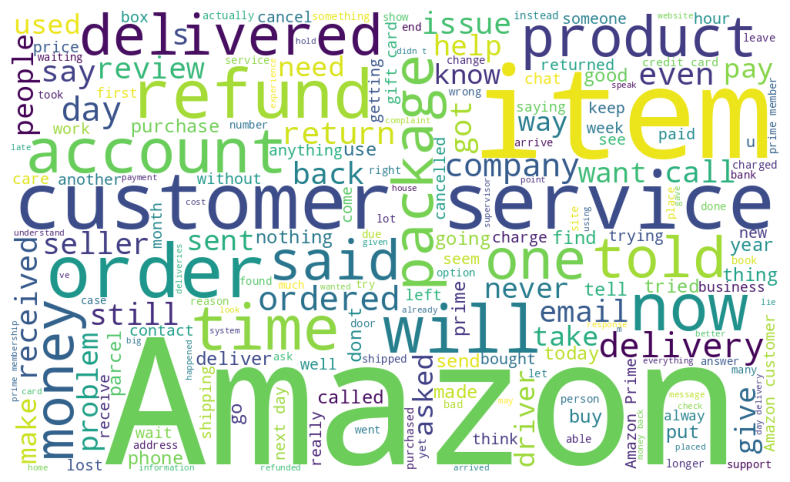

In [ ]:
wc = WordCloud(
    width=1000,
    height=600,
    background_color="white"
)

plt.figure(figsize=(12,6))

plt.imshow(
    wc.generate(negative)
)

plt.axis("off")

plt.savefig(
    "Shopease/outputs/figures/negative_wordcloud.png",
    dpi=300
)

plt.show()

####Top Words

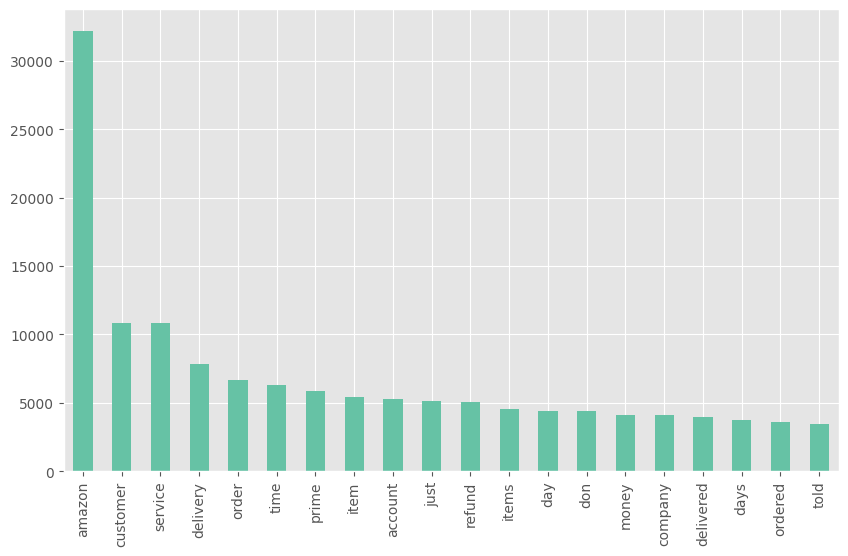

In [ ]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(
    df["review"]
)

counts = (
    pd.DataFrame(
        X.toarray(),
        columns=vectorizer.get_feature_names_out()
    )
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

counts.plot.bar()

plt.savefig(
    "Shopease/outputs/figures/top_words.png",
    dpi=300
)

plt.show()

####Top Bigrams

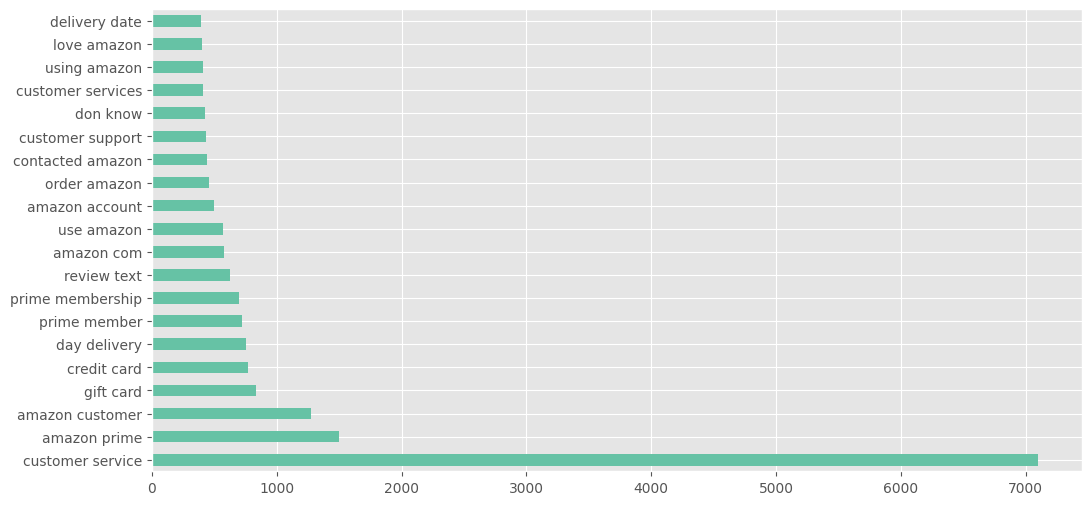

In [ ]:
bigram = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    max_features=20
)

X = bigram.fit_transform(
    df["review"]
)

bigrams = (
    pd.DataFrame(
        X.toarray(),
        columns=bigram.get_feature_names_out()
    )
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

bigrams.plot.barh()

plt.savefig(
    "Shopease/outputs/figures/top_bigrams.png",
    dpi=300
)

plt.show()

####Save Dataset

In [ ]:

os.makedirs("Shopease/data/processed", exist_ok=True)
df.to_csv(
    "Shopease/data/processed/eda_completed.csv",
    index=False
)